In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (5110, 12)

Columns:
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Data types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [5]:
sample = df.sample(frac=0.8, random_state=42)

print("Original dataset:", df.shape)
print("Sample dataset:", sample.shape)

sample.head()

Original dataset: (5110, 12)
Sample dataset: (4088, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4688,40041,Male,31.0,0,0,No,Self-employed,Rural,64.85,23.0,Unknown,0
4478,55244,Male,40.0,0,0,Yes,Self-employed,Rural,65.29,28.3,never smoked,0
3849,70992,Female,8.0,0,0,No,children,Urban,74.42,22.5,Unknown,0
4355,38207,Female,79.0,1,0,Yes,Self-employed,Rural,76.64,19.5,never smoked,0
3826,8541,Female,75.0,0,0,Yes,Govt_job,Rural,94.77,27.2,never smoked,0


In [6]:
print(sample["stroke"].value_counts())

stroke
0    3882
1     206
Name: count, dtype: int64


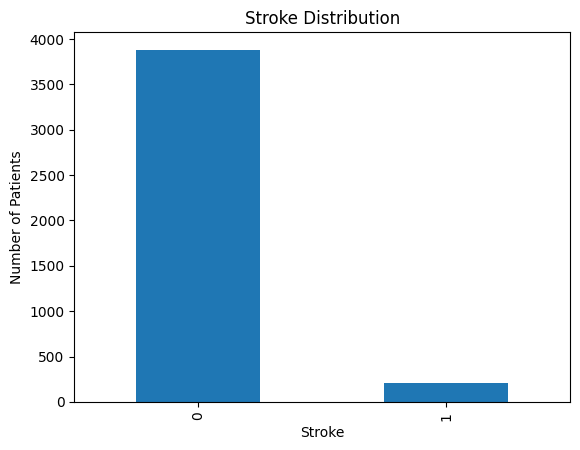

In [7]:
sample["stroke"].value_counts().plot(kind="bar")

plt.xlabel("Stroke")
plt.ylabel("Number of Patients")
plt.title("Stroke Distribution")
plt.show()

In [8]:
sample["bmi"] = sample["bmi"].fillna(sample["bmi"].median())

print("Missing values after modification:")
print(sample.isnull().sum())

Missing values after modification:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [9]:
sample = sample.drop("id", axis=1)

sample.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4688,Male,31.0,0,0,No,Self-employed,Rural,64.85,23.0,Unknown,0
4478,Male,40.0,0,0,Yes,Self-employed,Rural,65.29,28.3,never smoked,0
3849,Female,8.0,0,0,No,children,Urban,74.42,22.5,Unknown,0
4355,Female,79.0,1,0,Yes,Self-employed,Rural,76.64,19.5,never smoked,0
3826,Female,75.0,0,0,Yes,Govt_job,Rural,94.77,27.2,never smoked,0


In [10]:
sample = pd.get_dummies(sample, drop_first=True)

sample.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
4688,31.0,0,0,64.85,23.0,0,True,False,False,False,False,True,False,False,False,False,False
4478,40.0,0,0,65.29,28.3,0,True,False,True,False,False,True,False,False,False,True,False
3849,8.0,0,0,74.42,22.5,0,False,False,False,False,False,False,True,True,False,False,False
4355,79.0,1,0,76.64,19.5,0,False,False,True,False,False,True,False,False,False,True,False
3826,75.0,0,0,94.77,27.2,0,False,False,True,False,False,False,False,False,False,True,False


In [11]:
X = sample.drop("stroke", axis=1)
y = sample["stroke"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4088, 16)
y shape: (4088,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9511002444987775

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       778
           1       0.00      0.00      0.00        40

    accuracy                           0.95       818
   macro avg       0.48      0.50      0.49       818
weighted avg       0.90      0.95      0.93       818



C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod